In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
%matplotlib inline

# 2. Data Collection (Carga del dataset entregado)
df = pd.read_csv("data/bank_term_deposit.csv")
print(f"Dimensiones originales del dataset: {df.shape}")
print(df.info())
display(df.head())

Dimensiones originales del dataset: (3063, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3063 entries, 0 to 3062
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         3063 non-null   int64 
 1   split      3063 non-null   object
 2   age        3063 non-null   int64 
 3   job        3063 non-null   object
 4   marital    3063 non-null   object
 5   education  3063 non-null   object
 6   default    3063 non-null   object
 7   balance    3063 non-null   int64 
 8   housing    3063 non-null   object
 9   loan       3063 non-null   object
 10  contact    3063 non-null   object
 11  day        3063 non-null   int64 
 12  month      3063 non-null   object
 13  duration   3063 non-null   int64 
 14  campaign   3063 non-null   int64 
 15  pdays      3063 non-null   int64 
 16  previous   3063 non-null   int64 
 17  poutcome   3063 non-null   object
 18  y          2007 non-null   object
dtypes: int64(8), object(11

,id,split,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1,labeled,31,management,married,tertiary,no,460,no,no,cellular,28,aug,13,14,-1,0,unknown,no
1,2,labeled,34,blue-collar,married,secondary,no,1826,yes,no,unknown,20,may,203,2,-1,0,unknown,no
2,3,labeled,50,blue-collar,married,secondary,no,290,yes,no,cellular,7,aug,226,3,-1,0,unknown,no
3,4,labeled,42,admin.,divorced,secondary,no,1077,yes,no,unknown,14,may,213,1,-1,0,unknown,no
4,5,labeled,47,services,single,secondary,no,41,yes,no,cellular,5,may,298,1,-1,0,unknown,no


--- Distribución de la Variable Target ('y') ---
y
no     0.913303
yes    0.086697
Name: proportion, dtype: float64


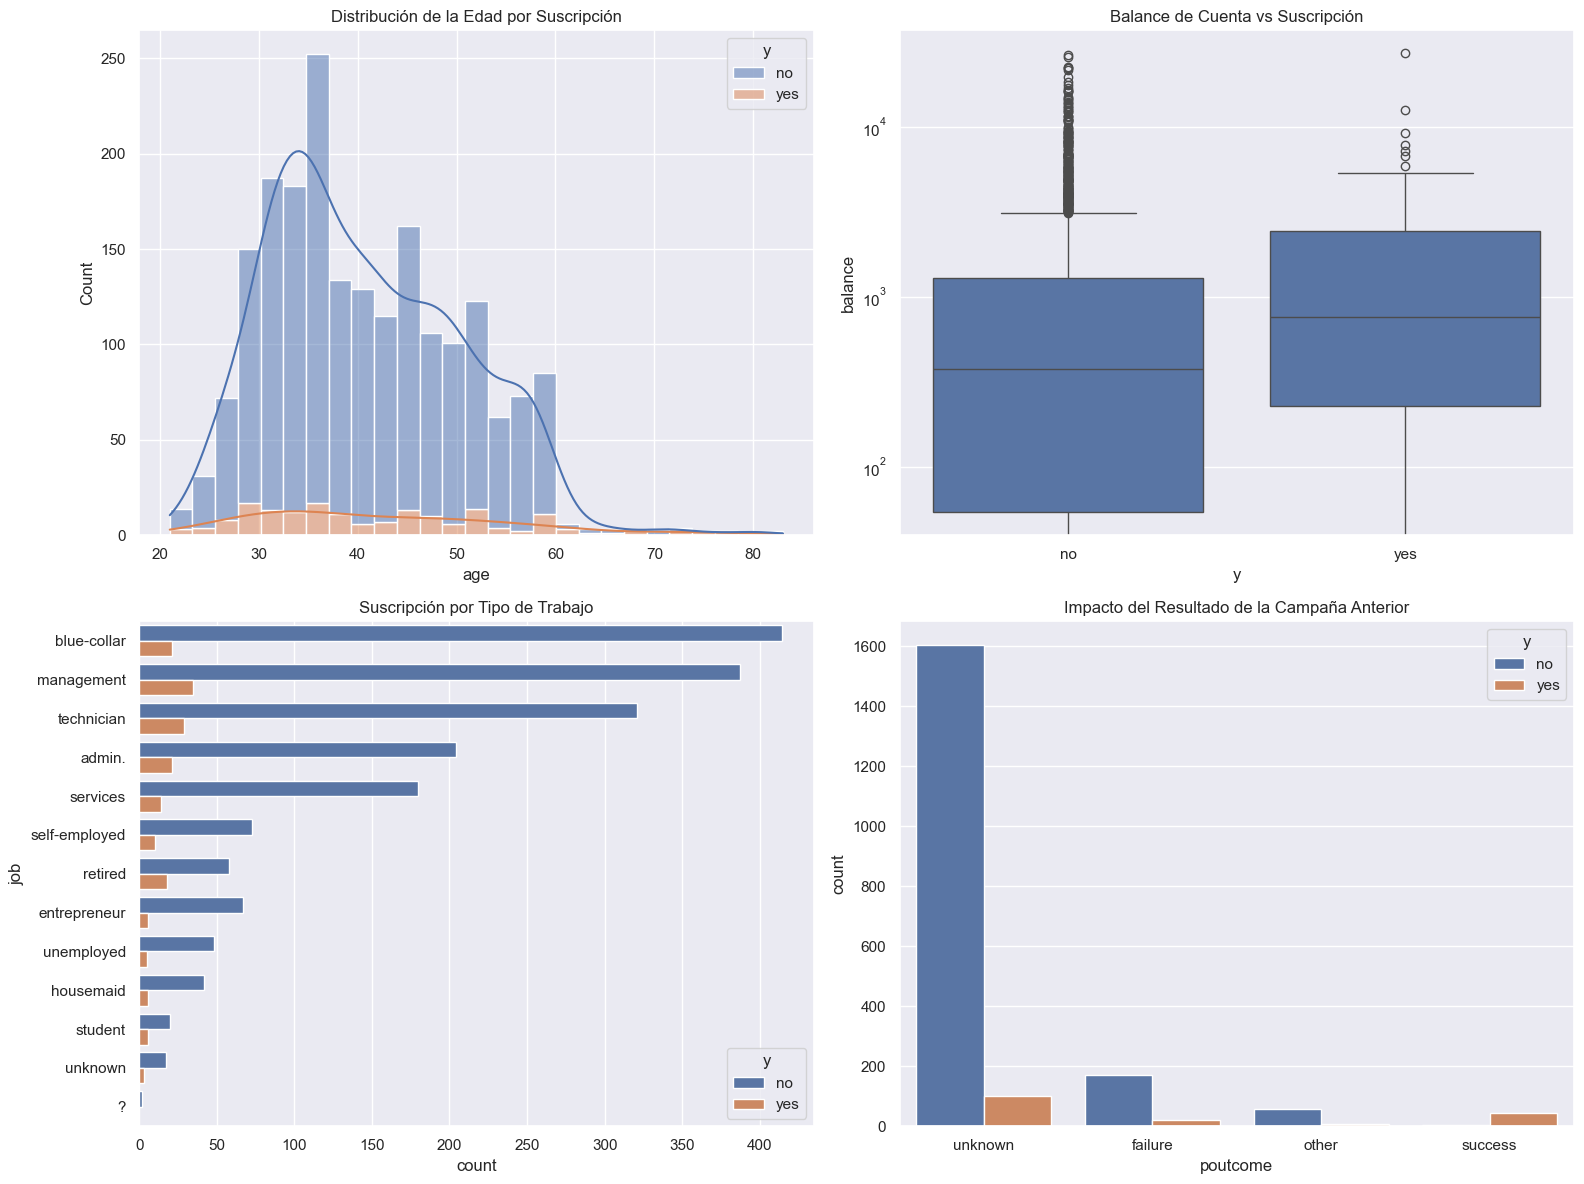


--- Análisis de la duración de la llamada ---
y
no     168.653028
yes    594.488506
Name: duration, dtype: float64


In [2]:
# Separamos temporalmente el set de entrenamiento/análisis para el EDA
df_train_eda = df[df['split'] == 'labeled'].copy()

print("--- Distribución de la Variable Target ('y') ---")
print(df_train_eda['y'].value_counts(normalize=True))

# Visualización de variables clave
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de la Edad
sns.histplot(data=df_train_eda, x='age', hue='y', multiple='stack', kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribución de la Edad por Suscripción')

# 2. Balance de cuenta (con escala logarítmica para manejar outliers visualmente)
sns.boxplot(data=df_train_eda, x='y', y='balance', ax=axes[0,1])
axes[0,1].set_title('Balance de Cuenta vs Suscripción')
axes[0,1].set_yscale('log') # Escala logarítmica para mejor visualización

# 3. Trabajo vs Suscripción
sns.countplot(data=df_train_eda, y='job', hue='y', order=df_train_eda['job'].value_counts().index, ax=axes[1,0])
axes[1,0].set_title('Suscripción por Tipo de Trabajo')

# 4. Resultado de campaña anterior
sns.countplot(data=df_train_eda, x='poutcome', hue='y', ax=axes[1,1])
axes[1,1].set_title('Impacto del Resultado de la Campaña Anterior')

plt.tight_layout()
plt.show()

# Análisis de la variable 'duration'
print("\n--- Análisis de la duración de la llamada ---")
print(df_train_eda.groupby('y')['duration'].mean())

In [3]:
# 1. Copia de seguridad y eliminación de duplicados (basado en el ID si aplica)
df_cleaned = df.drop_duplicates(subset=['id']).copy()

# 2. Identificar filas de entrenamiento para el cálculo de métricas
is_train = df_cleaned['split'] == 'labeled'

# 3. Tratamiento de valores nulos / "unknown"
# En este dataset, los nulos vienen vectorizados como la cadena 'unknown'
print("Valores 'unknown' por columna en Train:")
for col in df_cleaned.columns:
    unknown_count = (df_cleaned[is_train][col] == 'unknown').sum()
    if unknown_count > 0:
        print(f" - {col}: {unknown_count}")

# Imputamos 'unknown' en variables categóricas críticas usando la moda de TRAIN
for col in ['job', 'education', 'contact']:
    moda_train = df_cleaned[is_train][col].mode()[0]
    if moda_train == 'unknown':
        # Si la moda es unknown, tomamos la segunda más frecuente
        moda_train = df_cleaned[is_train][col].value_counts().index[1]

    # Aplicamos el reemplazo a todo el dataset
    df_cleaned[col] = df_cleaned[col].replace('unknown', moda_train)

# 4. Tratamiento de Outliers en Variables Numéricas (Balance y Duration)
# Filtramos outliers extremos basados en el percentil 99 de TRAIN para evitar distorsiones
q_balance_high = df_cleaned[is_train]['balance'].quantile(0.99)
q_balance_low = df_cleaned[is_train]['balance'].quantile(0.01)
q_duration_high = df_cleaned[is_train]['duration'].quantile(0.99)

# Reemplazamos los valores fuera de rango (Capping) para no perder filas en la predicción final
df_cleaned['balance'] = df_cleaned['balance'].clip(lower=q_balance_low, upper=q_balance_high)
df_cleaned['duration'] = df_cleaned['duration'].clip(upper=q_duration_high)

# 5. Feature Engineering (Creación de nuevas variables)
# Feature A: Cliente contactado previamente (Binario)
df_cleaned['was_contacted_before'] = np.where(df_cleaned['pdays'] == -1, 0, 1)

# Feature B: Ratio de contactos en esta campaña vs total histórico aproximado
df_cleaned['campaign_intensity'] = df_cleaned['campaign'] / (df_cleaned['previous'] + 1)

# Feature C: Edad por rangos (Binned Age) para capturar comportamiento no lineal
df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=[0, 30, 45, 60, 100], labels=['joven', 'adulto_joven', 'adulto', 'senior'])

# Feature D: Estacionalidad (Quarter en base al mes)
month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
df_cleaned['month_num'] = df_cleaned['month'].map(month_map)
df_cleaned['quarter'] = pd.cut(df_cleaned['month_num'], bins=[0, 3, 6, 9, 12], labels=['Q1', 'Q2', 'Q3', 'Q4']).astype(str)

# 6. Descartar Features Redundantes o Irrelevantes
# Eliminamos 'month_num' que solo sirvió para el cálculo y 'pdays' ya que tenemos 'was_contacted_before'
features_to_drop = ['month_num']
df_cleaned.drop(columns=features_to_drop, inplace=True)

print("\nDataset procesado con éxito.")
print(f"Dimensiones finales: {df_cleaned.shape}")

Valores 'unknown' por columna en Train:
 - job: 20
 - education: 65
 - contact: 668
 - poutcome: 1705

Dataset procesado con éxito.
Dimensiones finales: (3063, 23)


In [5]:
# Crear carpeta data_prepared si no existe
output_dir = "data_prepared"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Guardar el CSV preparado
output_path = os.path.join(output_dir, "bank_term_deposit_prepared.csv")
df_cleaned.to_csv(output_path, index=False)

print(f"¡Todo listo! El archivo limpio y enriquecido se ha guardado en: '{output_path}'")

¡Todo listo! El archivo limpio y enriquecido se ha guardado en: 'data_prepared\bank_term_deposit_prepared.csv'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# 1. Carregar el dataset preparat en el pas anterior
df_prepared = pd.read_csv("data_prepared/bank_term_deposit_prepared.csv")

# Separar el set amb etiquetes (labeled) i el de test/competició (leaderboard)
df_labeled = df_prepared[df_prepared['split'] == 'labeled'].copy()
df_leaderboard = df_prepared[df_prepared['split'] == 'leaderboard'].copy()

# En el set 'labeled', separem les features (X) del target (y)
# Mantenim l'ID per si de cas, però no s'ha d'usar per entrenar
X_labeled = df_labeled.drop(columns=['id', 'split', 'y'])
y_labeled = df_labeled['y'].map({'yes': 1, 'no': 0}) # Codifiquem el target numèricament

# Per al leaderboard no tenim target, només les features
X_leaderboard = df_leaderboard.drop(columns=['id', 'split', 'y'])

# 2. Definir quines columnes són numèriques i quines categòriques
numeric_features = [
    'age', 'balance', 'day', 'duration', 'campaign',
    'pdays', 'previous', 'was_contacted_before', 'campaign_intensity'
]

categorical_features = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome', 'age_group', 'quarter'
]

# 3. Crear els pipelines de transformació (Preprocessors)
# Utilitzem ColumnTransformer per aplicar canvis específics segons el tipus de dada

# A) Per a dades numèriques: Imputem amb la mediana i escalem (StandardScaler)
# L'escalat és crucial per a models lineals (LogReg, SVM) i xarxes neuronals.
numeric_transformer = ColumnTransformer(transformers=[
    ('num_imputer', SimpleImputer(strategy='median'), numeric_features)
])

# B) Per a dades categòriques: Imputem amb el valor més freqüent (moda) i apliquem One-Hot Encoding
categorical_transformer = ColumnTransformer(transformers=[
    ('cat_imputer', SimpleImputer(strategy='most_frequent'), categorical_features)
])

# 4. AJUSTAR ELS TRANSFORMADORS NOMÉS AMB LES DADES DE TRAIN (Evita Data Leakage)
# Primer extraiem i processem les dades netes de train
X_train_num_clean = numeric_transformer.fit_transform(X_labeled[numeric_features])
X_train_cat_clean = categorical_transformer.fit_transform(X_labeled[categorical_features])

# Ara configurem els encoders i scalers definitius basant-nos NOMÉS en train
scaler = StandardScaler()
scaler.fit(X_train_num_clean)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_cat_clean)

# 5. funció per transformar qualsevol subset (Train o Leaderboard) de forma segura
def pipeline_transform(X_df):
    # Imputació
    num_imputed = numeric_transformer.transform(X_df[numeric_features])
    cat_imputed = categorical_transformer.transform(X_df[categorical_features])

    # Escalat i Encoding
    num_scaled = scaler.transform(num_imputed)
    cat_encoded = encoder.transform(cat_imputed)

    # Concatenem les features numèriques escalades i les categòriques binàries
    X_transformed = np.hstack((num_scaled, cat_encoded))
    return X_transformed

# 6. Transformació final de les dades
X_labeled_processed = pipeline_transform(X_labeled)
X_leaderboard_processed = pipeline_transform(X_leaderboard)

# Obtenir els noms de les columnes transformades per a transparència
encoded_cat_names = encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

print("--- Procés de Feature Engineering Finalitzat ---")
print(f"Dimensions de X_labeled processat (Train/Validació): {X_labeled_processed.shape}")
print(f"Dimensions de X_leaderboard processat (A avaluar): {X_leaderboard_processed.shape}")
print(f"Número total de features després del One-Hot Encoding: {len(all_feature_names)}")
print(f"Target 'y' (labeled) convertit a binari (0/1).")